# Exploratory Data Analysis - Multivariate EDA

**Contributors:**  
Kunal Kulkarni,  
Naim Hadzic

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

---
## Task 1: Autonomous Vehicle Survey of Bicyclists and Pedestrians in Pittsburgh

Load the **survey data for 2019**.

- Is **BikePgh membership** and **previous experience of encountering autonomous vehicles as a pedestrian** related to the **approval of Pittsburgh as a proving ground**? Examine this question in the following way:
  - Compute a **contingency table** that displays the relationship between the relevant variables. Restrict membership and experience to **"yes" and "no"** answers and ensure a **meaningful order** for all ordinal features.
  - Create a **heatmap** of the **relative** frequencies.
  - Add your **interpretation** of the results in markdown.

In [32]:
# Load the survey data for 2019
# Load the combined 2019 survey data prepared in the previous lab (adjust filepath if needed)
df_av = pd.read_csv("data/av_survey_data/avsurvey2019data.csv", encoding="latin-1")
print(f"Shape: {df_av.shape}")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
df_av.head()

Shape: (795, 23)


,RespondentID,StartDate,EndDate,FamiliarityNews,FamiliarityTech,SharedCyclist,SharedPedestrian,SafeAv,SafeHuman,AvImpact,ProvingGround,Speed25Mph,TwoEmployeesAv,SchoolZoneManual,ShareTripData,SharePerformanceData,ReportSafetyIncident,ArizonaCrash,ZipCode,BikePghMember,AutoOwner,SmartphoneOwner,Age
0,10505419886,2/2/2019,2/2/2019,To a moderate extent,Somewhat familiar,Yes,Yes,4.0,2.0,Significantly Better,Approve,No,Not sure,No,Not sure,Yes,Yes,No change,15212,No,Yes,Yes,25-34
1,10505138734,2/2/2019,2/2/2019,To a moderate extent,Somewhat familiar,Yes,No,5.0,4.0,Significantly Better,Neutral,No,No,No,No,Yes,Not sure,No change,15232,Not sure,Yes,Yes,25-34
2,10504803283,2/1/2019,2/1/2019,To a moderate extent,Somewhat familiar,Yes,Yes,1.0,4.0,Significantly Worse,Disapprove,Not sure,Yes,No,No,No,Not sure,Significantly more negative opinion,NaN,No,No,No,NaN
3,10504337177,2/1/2019,2/1/2019,To a moderate extent,Extremely familiar,Yes,Yes,2.0,3.0,Slightly Worse,Disapprove,Yes,Yes,Yes,No,Yes,Yes,No change,15136,No,No,Yes,55-64
4,10504261546,2/1/2019,2/1/2019,To a moderate extent,Mostly familiar,Yes,No,5.0,3.0,Slightly Better,Neutral,No,No,Not sure,Yes,Yes,No,No change,15201,Yes,No,Yes,35-44


In [33]:
df_av_filtered = df_av[
    (df_av['BikePghMember'].isin(['Yes', 'No'])) &
    (df_av['SharedPedestrian'].isin(['Yes', 'No'])) &
    (df_av['ProvingGround'].isin(['Approve', 'Neutral', 'Disapprove', 'Somewhat Disapprove', 'Somewhat Approve']))
].copy()

# Meaningful ordinal order: most negative → most positive
proving_ground_order = ['Disapprove', 'Somewhat Disapprove', 'Neutral', 'Somewhat Approve', 'Approve']
df_av_filtered['ProvingGround'] = pd.Categorical(
    df_av_filtered['ProvingGround'],
    categories=proving_ground_order,
    ordered=True
)

contingency_table = pd.crosstab(
    index=[df_av_filtered['BikePghMember'], df_av_filtered['SharedPedestrian']],
    columns=df_av_filtered['ProvingGround'],
    margins=True
)

contingency_table.index.names = ['BikePgh Member', 'Shared w/ Pedestrian']
contingency_table.columns = contingency_table.columns.astype(str)
contingency_table.columns.name = 'Proving Ground Approval'

# Use iloc[-1] to safely get the grand total scalar from the 'All' margin row
grand_total = contingency_table['All'].iloc[-1]

for col in proving_ground_order + ['All']:
    contingency_table[f'{col} (%)'] = (contingency_table[col] / grand_total).map('{:.1%}'.format)

contingency_table

Proving Ground Approval              Disapprove  Somewhat Disapprove  Neutral  \
BikePgh Member Shared w/ Pedestrian                                             
No             No                            16                    9       16   
               Yes                           14                   20       19   
Yes            No                             8                   11       14   
               Yes                           16                   23       18   
All                                          54                   63       67   

Proving Ground Approval              Somewhat Approve  Approve  All  \
BikePgh Member Shared w/ Pedestrian                                   
No             No                                  22       43  106   
               Yes                                 37      101  191   
Yes            No                                  29       55  117   
               Yes                                 52      132  241   
All                                               140      331  655   

Proving Ground Approval             Disapprove (%) Somewhat Disapprove (%)  \
BikePgh Member Shared w/ Pedestrian                                          
No             No                             2.4%                    1.4%   
               Yes                            2.1%                    3.1%   
Yes            No                             1.2%                    1.7%   
               Yes                            2.4%                    3.5%   
All                                           8.2%                    9.6%   

Proving Ground Approval             Neutral (%) Somewhat Approve (%)  \
BikePgh Member Shared w/ Pedestrian                                    
No             No                          2.4%                 3.4%   
               Yes                         2.9%                 5.6%   
Yes            No                          2.1%                 4.4%   
               Yes                         2.7%                 7.9%   
All                                       10.2%                21.4%   

Proving Ground Approval             Approve (%) All (%)  
BikePgh Member Shared w/ Pedestrian                      
No             No                          6.6%   16.2%  
               Yes                        15.4%   29.2%  
Yes            No                          8.4%   17.9%  
               Yes                        20.2%   36.8%  
All                                       50.5%  100.0%

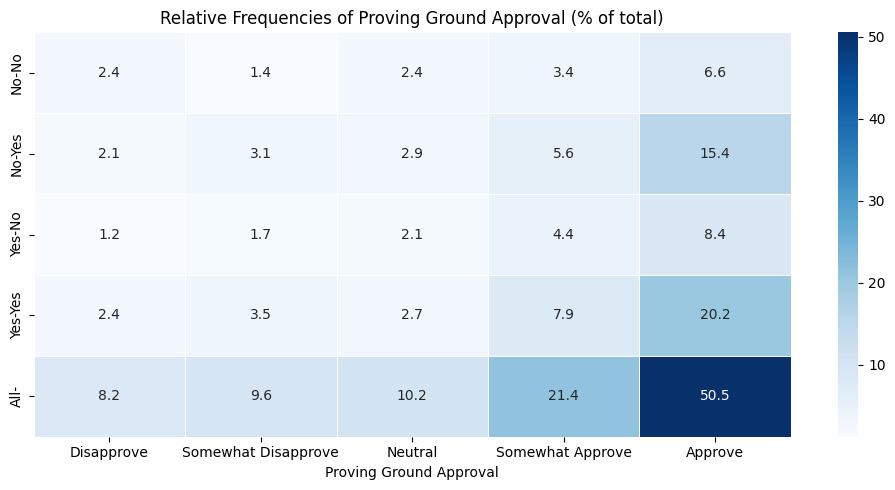

In [34]:
# Relative frequencies for heatmap: exclude margins, divide by grand total
pct = df_av_filtered.value_counts(normalize=True, dropna=False).mul(100).round(1)
heatmap_data = contingency_table.loc[
    contingency_table.index.get_level_values(-1) != 'All',
    proving_ground_order
].div(grand_total) * 100

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5)
plt.title('Relative Frequencies of Proving Ground Approval (% of total)')
plt.xlabel('Proving Ground Approval')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Interpretation:**

*(Add your interpretation of the contingency table and heatmap here.)*

---
- To investigate the **relationship between the perceived safety** in the presence of autonomous vs. manually driven vehicles:
  - Compute **Kendall's tau**
  - Display a **heatmap of the relative frequencies** for all categories
  
  Add your interpretation of the results in markdown. **How does the information differ between the heatmap and the correlation coefficient?**

In [35]:
# Compute Kendall's tau between SafeAv and SafeHuman
# Hint: use scipy.stats.kendalltau
from scipy import stats


In [36]:
# Compute a crosstab of SafeAv vs SafeHuman (all rating categories)

# Convert to relative frequencies

# Display as a heatmap


**Interpretation:**

*(Interpret Kendall's tau and the heatmap. How does the information differ between the two?)*

---
- Are **respondents who feel safe around autonomous vehicles** equally likely to **argue for a 25-mph speed limit**?  
  Use a **bar chart** to investigate this question and explain your observations.  
  Restrict answers to the question on speed limits to **"yes" and "no"**.

In [37]:
# Filter: restrict speed limit answers to 'Yes' and 'No' only

# Group by SafeAv rating and compute the proportion/count arguing for 25-mph speed limit

# Create a bar chart showing the relationship


**Interpretation:**

*(Explain your observations from the bar chart.)*

---
## Task 2: Degradation Measurement of Robot Arm Position Accuracy

- Compute the **maximum deviation in both directions** (positive and negative) between the actual and the target joint position **for each trial and joint**.
- Compute the **point-biserial correlations** between the resulting metrics and the **speed** as well as the **load condition**. Describe your findings.

In [38]:
import ast
import os

# Define the path to the robot arm data folder
DATA_PATH = 'data/robot_position_accuracy/'

# List all available trial files


In [39]:
# Parse all trial files and compute the max positive and max negative deviation
# for each joint (J1–J6) per trial.
#
# Hint: the filename encodes the experimental condition, e.g.:
#   ur5testresult_fullspeed_payload4.5lb_1.csv  -> speed=full, load=4.5lb, trial=1
#   ur5testresult_coldstart_fullspeed_...        -> coldstart variant
#
# For each file:
#   1. Parse each row with ast.literal_eval
#   2. Compute error = actual - target for each joint
#   3. Record max_positive_deviation = max(error) and max_negative_deviation = min(error)
#   4. Extract speed and load condition from the filename as binary/categorical labels

results = []

# --- your loop over files here ---

df_trials = pd.DataFrame(results)
df_trials.head()

""


In [40]:
# Compute point-biserial correlations between the deviation metrics and:
#   - speed condition (binary: e.g. full speed = 1, reduced = 0)
#   - load condition (binary: e.g. high load = 1, low/no load = 0)
#
# Hint: use scipy.stats.pointbiserialr


**Findings:**

*(Describe the point-biserial correlation results. Which joints/directions are most affected by speed or load?)*